#EDA

In [212]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
print("Loaded Library")

Loaded Library


In [213]:
#load the Sales Data from Dataset
df_sales = pd.read_csv("/content/Datasets/sales.csv")
print("Loaded Sales Dataset")
df_sales

Loaded Sales Dataset


,date,item_id,price,item_count
0,2019-01-01,3,29.22,2.0
1,2019-01-01,4,26.42,22.0
2,2019-01-01,12,4.87,7.0
3,2019-01-01,13,4.18,12.0
4,2019-01-01,16,3.21,136.0
...,...,...,...,...
109595,2021-12-31,96,21.93,0.0
109596,2021-12-31,97,28.65,0.0
109597,2021-12-31,98,5.00,0.0
109598,2021-12-31,99,5.32,0.0


In [214]:
#load the Resturants Data from Dataset
df_resturants = pd.read_csv("/content/Datasets/resturants.csv")
print("Loaded Resturants Dataset")
df_resturants

Loaded Resturants Dataset


,id,name
0,1,Bob's Diner
1,2,Beachfront Bar
2,3,Sweet Shack
3,4,Fou Cher
4,5,Corner Cafe
5,6,Surfs Up


In [215]:
#load the items Data from Dataset
df_items = pd.read_csv("/content/Datasets/items.csv")
print("Loaded items Dataset")
df_items

Loaded items Dataset


,id,store_id,name,kcal,cost
0,1,4,Chocolate Cake,554,6.71
1,2,4,Breaded Fish with Vegetables Meal,772,15.09
2,3,1,Sweet Fruity Cake,931,29.22
3,4,1,Amazing Steak Dinner with Rolls,763,26.42
4,5,5,Milk Cake,583,6.07
...,...,...,...,...,...
95,96,5,Blue Ribbon Fish with Bread Lunch,708,21.93
96,97,4,Original Fruity Cod with Bread and Vegetables ...,744,28.65
97,98,2,Original Sweet Milky Soft Drink,579,5.00
98,99,4,Frozen Tomato Soft Drink,423,5.32


#Check the Datasets

In [217]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109600 entries, 0 to 109599
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   date        109600 non-null  object 
 1   item_id     109600 non-null  int64  
 2   price       109600 non-null  float64
 3   item_count  109600 non-null  float64
dtypes: float64(2), int64(1), object(1)
memory usage: 3.3+ MB


In [218]:
df_resturants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      6 non-null      int64 
 1   name    6 non-null      object
dtypes: int64(1), object(1)
memory usage: 228.0+ bytes


In [219]:
df_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        100 non-null    int64  
 1   store_id  100 non-null    int64  
 2   name      100 non-null    object 
 3   kcal      100 non-null    int64  
 4   cost      100 non-null    float64
dtypes: float64(1), int64(3), object(1)
memory usage: 4.0+ KB


above datasets are fine.

#Merge the Data

In [220]:
#merge the sales and item with item id

df_sales_items_merge = pd.merge(df_sales, df_items, left_on='item_id', right_on="id", how="left")
df_sales_items_merge

,date,item_id,price,item_count,id,store_id,name,kcal,cost
0,2019-01-01,3,29.22,2.0,3,1,Sweet Fruity Cake,931,29.22
1,2019-01-01,4,26.42,22.0,4,1,Amazing Steak Dinner with Rolls,763,26.42
2,2019-01-01,12,4.87,7.0,12,1,Fantastic Sweet Cola,478,4.87
3,2019-01-01,13,4.18,12.0,13,1,Sweet Frozen Soft Drink,490,4.18
4,2019-01-01,16,3.21,136.0,16,1,Frozen Milky Smoothy,284,3.21
...,...,...,...,...,...,...,...,...,...
109595,2021-12-31,96,21.93,0.0,96,5,Blue Ribbon Fish with Bread Lunch,708,21.93
109596,2021-12-31,97,28.65,0.0,97,4,Original Fruity Cod with Bread and Vegetables ...,744,28.65
109597,2021-12-31,98,5.00,0.0,98,2,Original Sweet Milky Soft Drink,579,5.00
109598,2021-12-31,99,5.32,0.0,99,4,Frozen Tomato Soft Drink,423,5.32


In [221]:
#now merge with Restarants
df_final_merged_data= pd.merge(df_sales_items_merge, df_resturants, left_on = 'store_id', right_on = 'id')
df_final_merged_data

,date,item_id,price,item_count,id_x,store_id,name_x,kcal,cost,id_y,name_y
0,2019-01-01,3,29.22,2.0,3,1,Sweet Fruity Cake,931,29.22,1,Bob's Diner
1,2019-01-01,4,26.42,22.0,4,1,Amazing Steak Dinner with Rolls,763,26.42,1,Bob's Diner
2,2019-01-01,12,4.87,7.0,12,1,Fantastic Sweet Cola,478,4.87,1,Bob's Diner
3,2019-01-01,13,4.18,12.0,13,1,Sweet Frozen Soft Drink,490,4.18,1,Bob's Diner
4,2019-01-01,16,3.21,136.0,16,1,Frozen Milky Smoothy,284,3.21,1,Bob's Diner
...,...,...,...,...,...,...,...,...,...,...,...
109595,2021-12-31,96,21.93,0.0,96,5,Blue Ribbon Fish with Bread Lunch,708,21.93,5,Corner Cafe
109596,2021-12-31,97,28.65,0.0,97,4,Original Fruity Cod with Bread and Vegetables ...,744,28.65,4,Fou Cher
109597,2021-12-31,98,5.00,0.0,98,2,Original Sweet Milky Soft Drink,579,5.00,2,Beachfront Bar
109598,2021-12-31,99,5.32,0.0,99,4,Frozen Tomato Soft Drink,423,5.32,4,Fou Cher


In [222]:
#Check item ids are all same
(df_final_merged_data.item_id==df_final_merged_data.id_x).all()

np.True_

#Rename and drop the unnecessary columns

In [223]:
#Rename the Columns
df_final_merged_data.rename(columns = {"name_x" : "item_name", "name_y": "restaurant_name"}, inplace = True)

In [224]:
#Drop the Columns
df_final_merged_data.drop(columns = ['id_x', 'id_y', 'cost'], inplace = True)

In [225]:
#Check the Data, 109600, 8 columns
df_final_merged_data.shape

(109600, 8)

#a. Examine the overall sales to understand the pattern

In [226]:
#Convert the Datetime column
df_final_merged_data['date'] = pd.to_datetime(df_final_merged_data['date'])

In [227]:
df_final_merged_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109600 entries, 0 to 109599
Data columns (total 8 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   date             109600 non-null  datetime64[ns]
 1   item_id          109600 non-null  int64         
 2   price            109600 non-null  float64       
 3   item_count       109600 non-null  float64       
 4   store_id         109600 non-null  int64         
 5   item_name        109600 non-null  object        
 6   kcal             109600 non-null  int64         
 7   restaurant_name  109600 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(3), object(2)
memory usage: 6.7+ MB


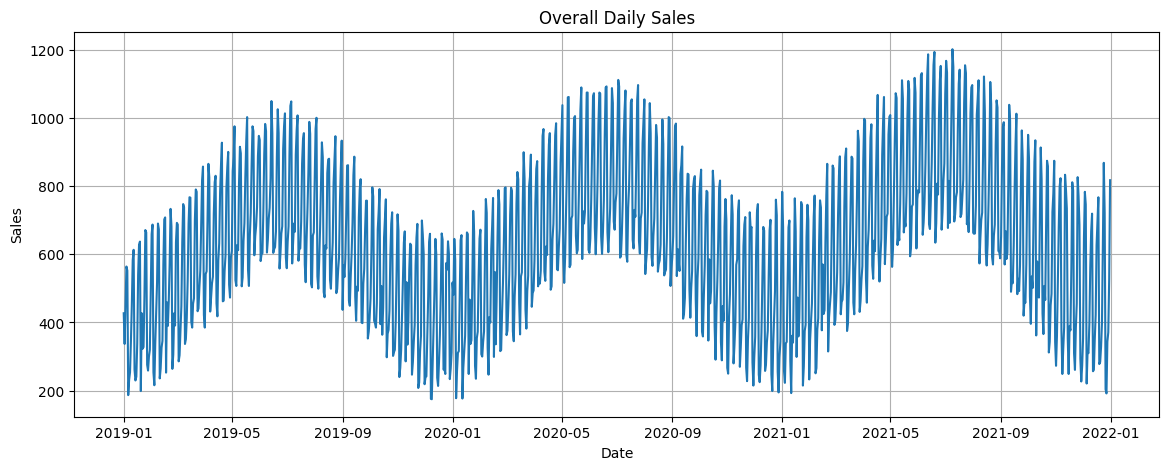

In [228]:
#Daily Sales by Item Count

daily_sales = df_final_merged_data.groupby('date')['item_count'].sum()
plt.figure(figsize=(14,5))
plt.plot(daily_sales)
plt.title("Overall Daily Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

#b. Find out how sales fluctuate across different days of the week

In [229]:
#Create the day of week column
df_final_merged_data['day_of_week'] = df_final_merged_data['date'].dt.day_name()


In [230]:
#Creat a weekday
df_final_merged_data['weekday'] = df_final_merged_data.date.dt.day_name()


In [231]:
#import calendar
import calendar as cal
day_names = list(cal.day_name)

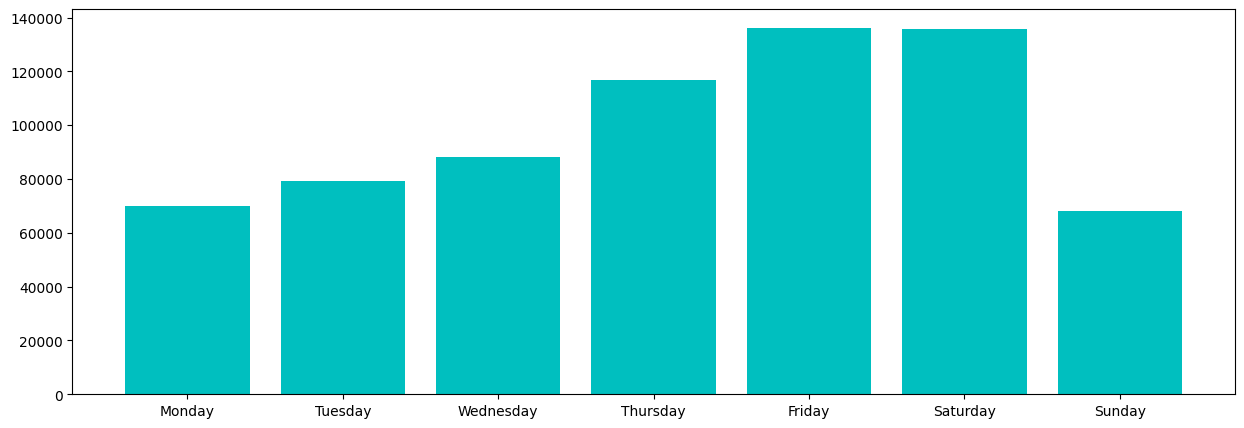

In [232]:
#Create the Chart

grpd = df_final_merged_data.groupby(['day_of_week'])[['item_count']].sum()
grpd = grpd.loc[day_names].squeeze()
plt.figure(figsize = (15,5))
plt.bar(height = grpd.values, x = grpd.index, color ='c')
plt.show()

#c.Look for any noticeable trends in the sales data for different months of the year
#d.Examine the sales distribution across different quarters averaged over the years. Identify any noticeable patterns.

In [233]:
#Create Month Name Column
df_final_merged_data['month_name'] = df_final_merged_data.date.dt.month_name()
#get Month Names
months = list(cal.month_name)[1:]

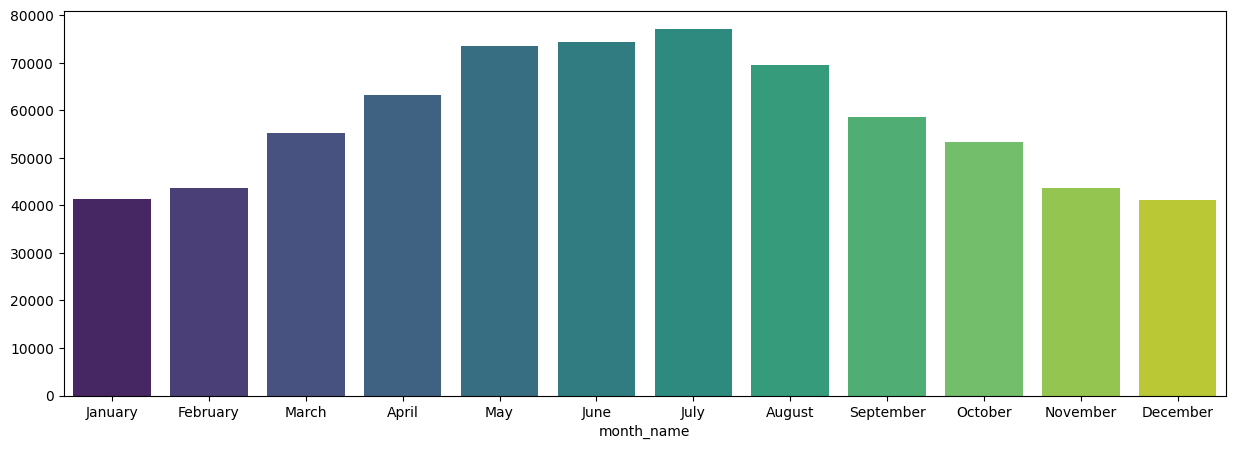

In [234]:
#create sales trend based on Months of the Year
grpd = df_final_merged_data.groupby(['month_name'])[['item_count']].sum()
grpd = grpd.loc[months].squeeze()
plt.figure(figsize = (15,5))
sns.barplot(y= grpd.values, x = grpd.index,palette='viridis')
plt.show()


0         1
1         1
2         1
3         1
4         1
         ..
109595    4
109596    4
109597    4
109598    4
109599    4
Name: quarter, Length: 109600, dtype: int32


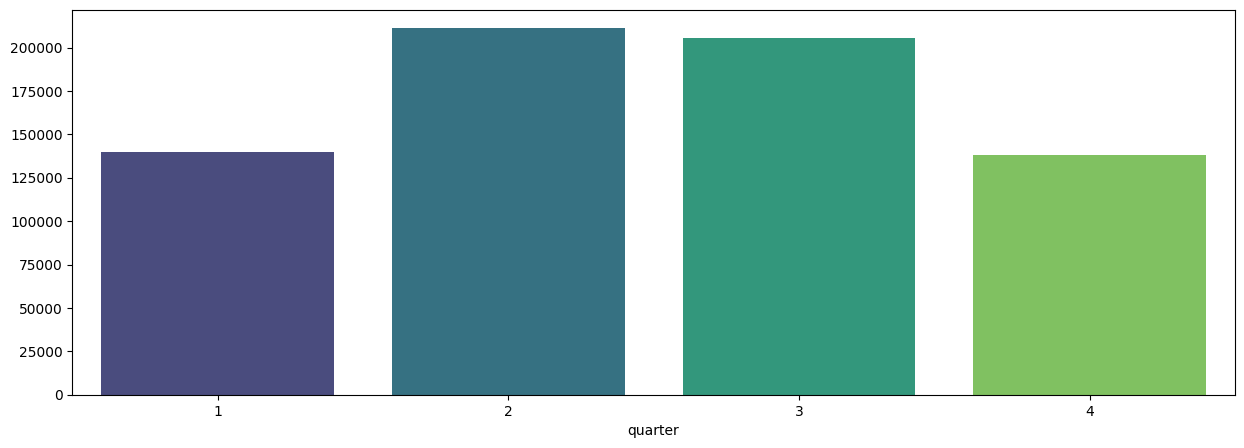

In [235]:
#Do for Quarter

df_final_merged_data['quarter'] = df_final_merged_data.date.dt.quarter

print(df_final_merged_data['quarter'] )

#create sales trend based on Quarter of the Year
grpd = df_final_merged_data.groupby(['quarter'])[['item_count']].sum().squeeze()
plt.figure(figsize = (15,5))
sns.barplot(y= grpd.values, x = grpd.index,palette='viridis')
plt.show()


 #e.Compare the performances of the different restaurants. Find out which restaurant had the most sales and look at the sales for each restaurant across different years, months, and days.

In [236]:
#Group by Store Id with Item Count, total items sold over the years on every store
df_final_merged_data.groupby(['store_id'])[['item_count']].sum()

,item_count
store_id,
1,687527.0
2,1305.0
3,1736.0
4,1106.0
5,1310.0
6,1803.0


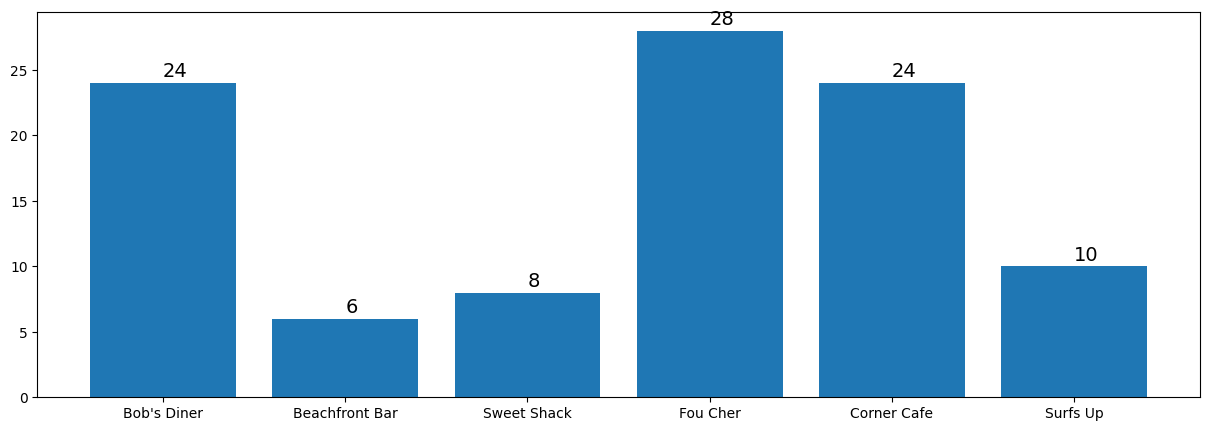

In [237]:
#Unique Items Sold
items_served=df_items.groupby(['store_id']).agg({'id' : "nunique"}).squeeze()
plt.figure(figsize = (15,5))
plt.bar(items_served.index, items_served.values)
plt.xticks(range(1,7), df_resturants.name)
for i in range(1,7):
  plt.annotate(items_served[i], xy = (i, items_served[i]+0.45), size = 14)
plt.show()
#Bob sold max number of items

#Store wise analysis

In [238]:
#Set the Style
pal = sns.color_palette()
pal_list = list(pal)

In [239]:
#Get the store wise numerical data according to the sales
plot_data = df_final_merged_data.pivot_table(index = 'date', columns = 'store_id',values = 'item_count', aggfunc = 'sum')
plot_data

store_id,1,2,3,4,5,6
date,,,,,,
2019-01-01,421.0,1.0,0.0,1.0,2.0,2.0
2019-01-02,330.0,1.0,1.0,2.0,1.0,2.0
2019-01-03,438.0,1.0,2.0,3.0,0.0,1.0
2019-01-04,559.0,2.0,2.0,1.0,0.0,0.0
2019-01-05,545.0,1.0,2.0,2.0,2.0,0.0
...,...,...,...,...,...,...
2021-12-27,184.0,2.0,2.0,2.0,0.0,2.0
2021-12-28,340.0,1.0,0.0,1.0,0.0,2.0
2021-12-29,366.0,1.0,2.0,0.0,1.0,1.0


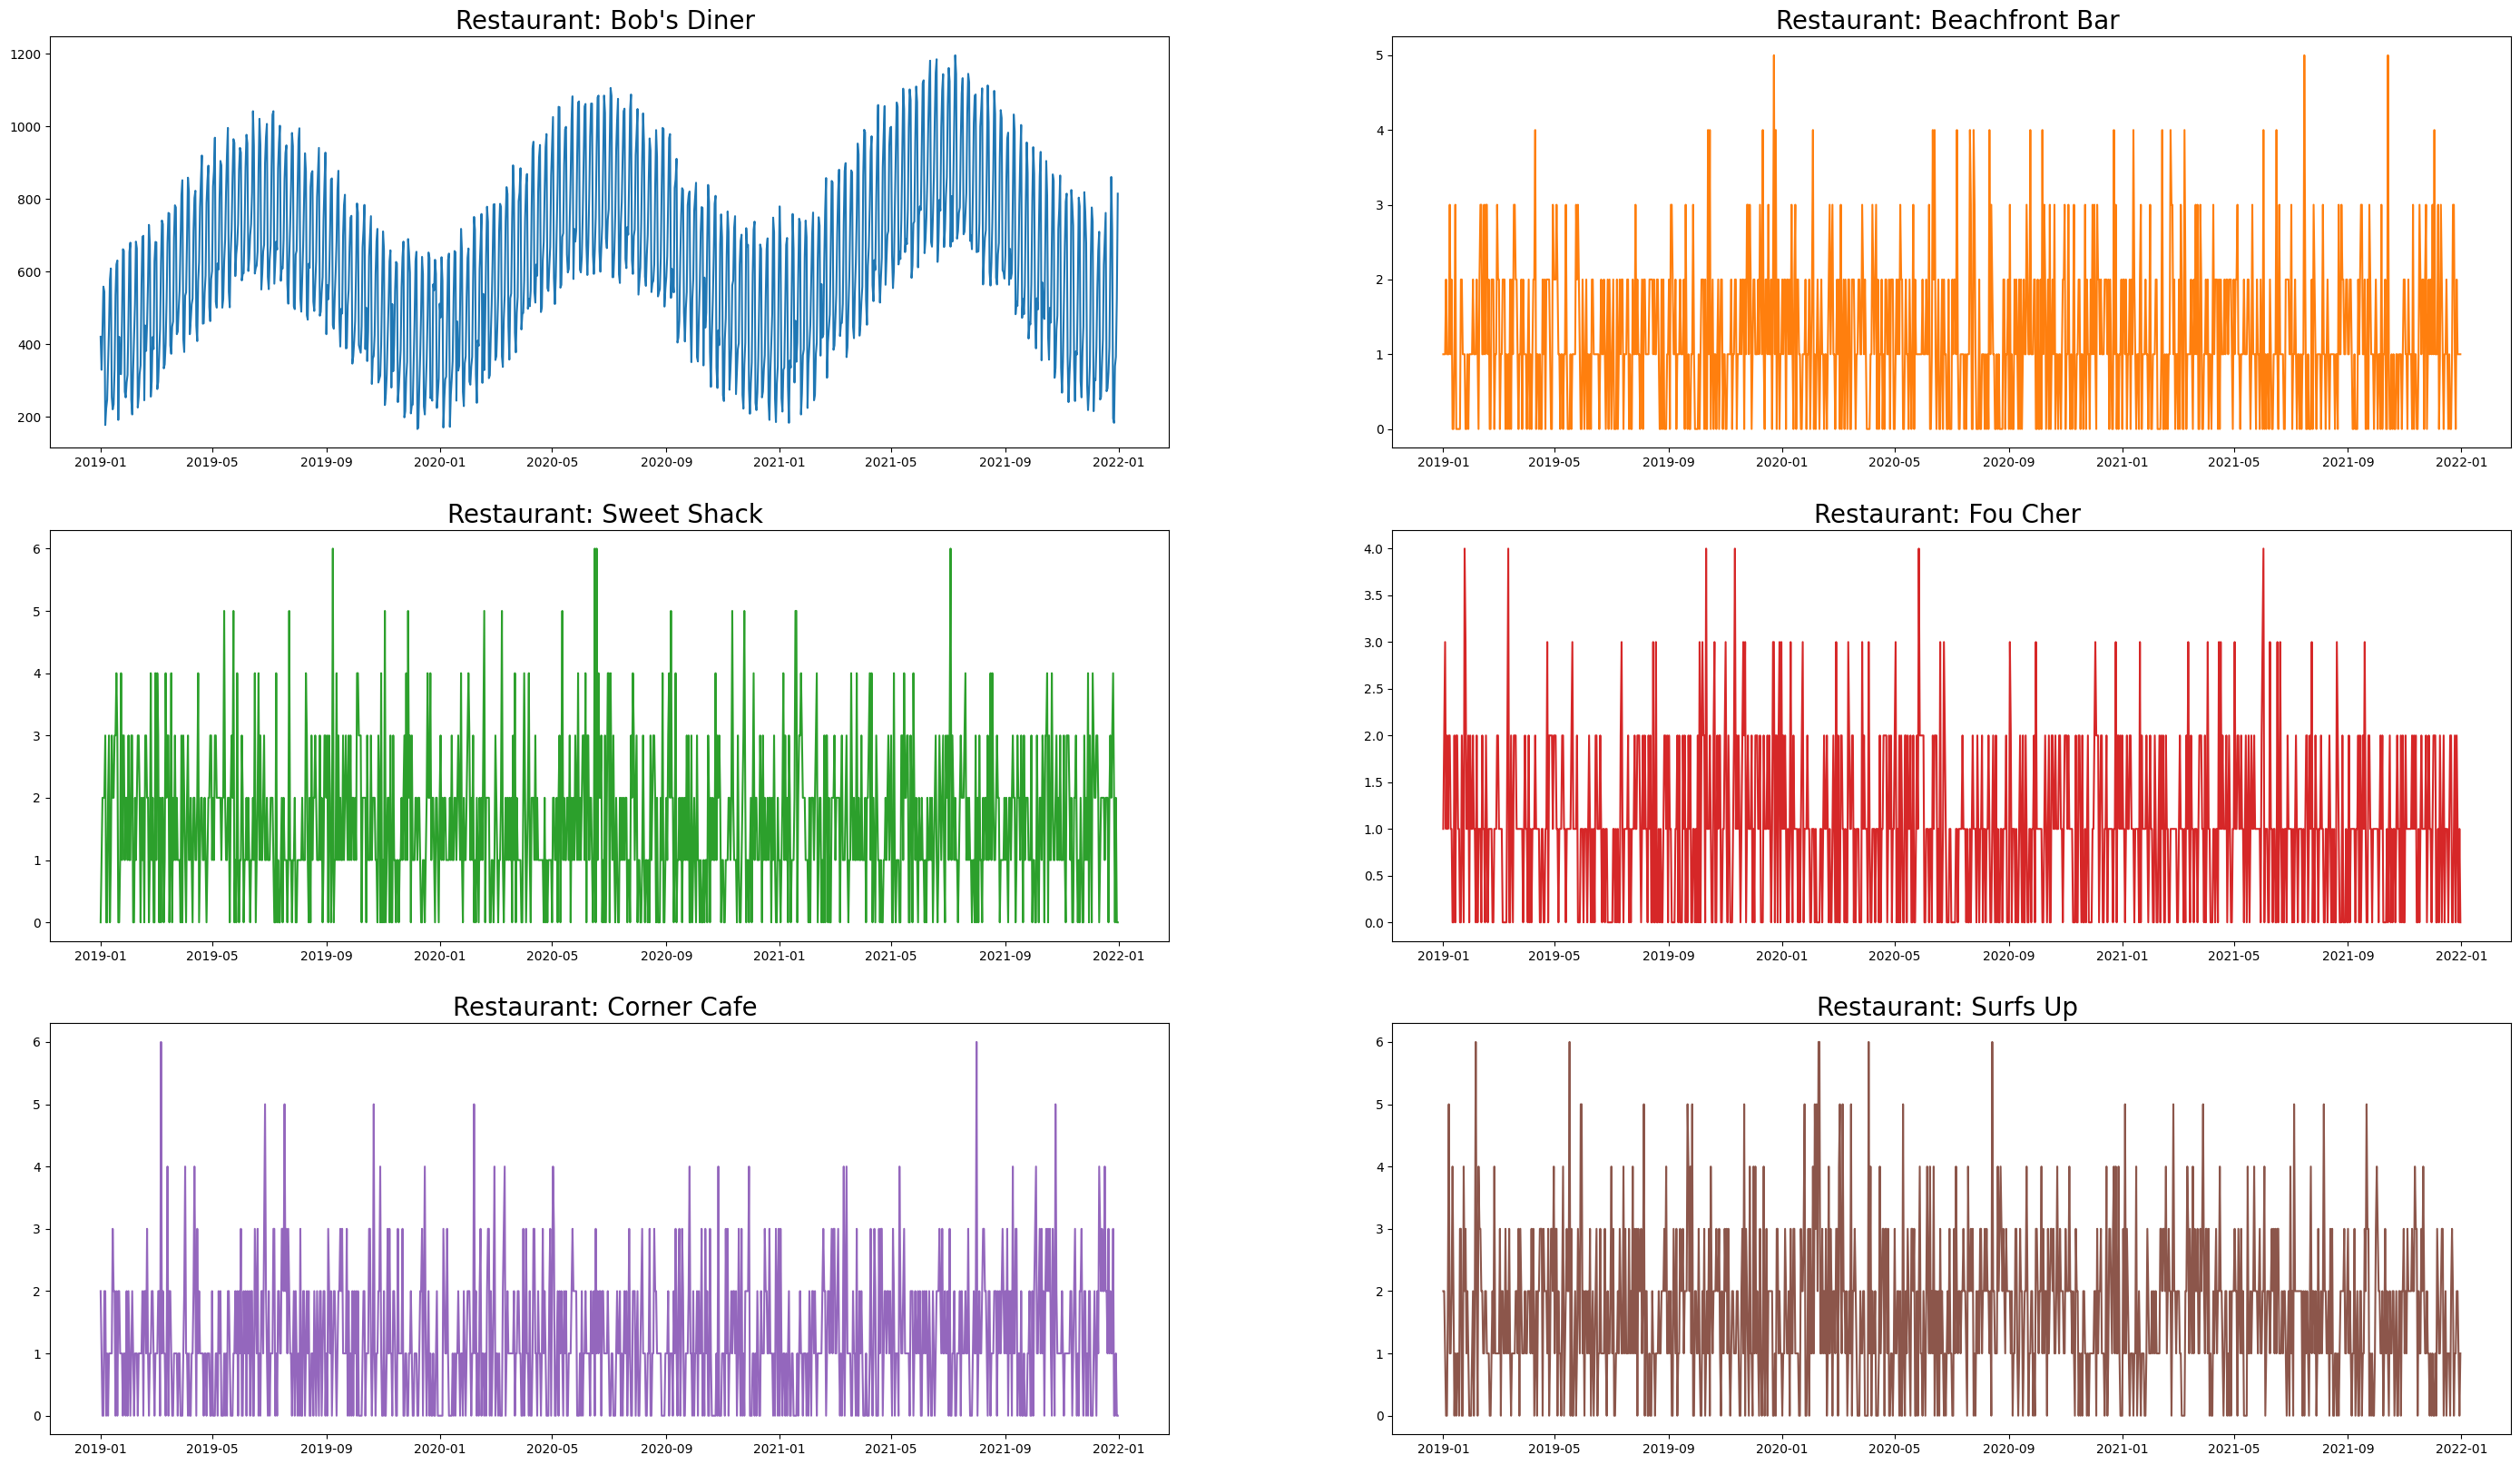

In [240]:
#Plot sales with resturant wise
f,ax = plt.subplots(3,2,figsize =(35,20) )
r,c = 0,0
for i in range(1,7):
  ax[r,c].plot(plot_data.loc[:, i], color = pal_list[i-1])
  ax[r,c].set_title('Restaurant: {} '.format(df_resturants.loc[df_resturants.id == i, 'name'].values[0]), size = 20)
  c += 1
  if c == 2:
    c = 0
    r +=1

#Year wise sales againts each store

In [241]:
#create the year and Quarter wise column in the table

#Year
df_final_merged_data['year'] = df_final_merged_data.date.dt.year
#Quarter
df_final_merged_data['quart-year'] = "Q" + df_final_merged_data.quarter.astype(str) + "-" + df_final_merged_data.year.astype(str)
df_final_merged_data
#

,date,item_id,price,item_count,store_id,item_name,kcal,restaurant_name,day_of_week,weekday,month_name,quarter,year,quart-year
0,2019-01-01,3,29.22,2.0,1,Sweet Fruity Cake,931,Bob's Diner,Tuesday,Tuesday,January,1,2019,Q1-2019
1,2019-01-01,4,26.42,22.0,1,Amazing Steak Dinner with Rolls,763,Bob's Diner,Tuesday,Tuesday,January,1,2019,Q1-2019
2,2019-01-01,12,4.87,7.0,1,Fantastic Sweet Cola,478,Bob's Diner,Tuesday,Tuesday,January,1,2019,Q1-2019
3,2019-01-01,13,4.18,12.0,1,Sweet Frozen Soft Drink,490,Bob's Diner,Tuesday,Tuesday,January,1,2019,Q1-2019
4,2019-01-01,16,3.21,136.0,1,Frozen Milky Smoothy,284,Bob's Diner,Tuesday,Tuesday,January,1,2019,Q1-2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109595,2021-12-31,96,21.93,0.0,5,Blue Ribbon Fish with Bread Lunch,708,Corner Cafe,Friday,Friday,December,4,2021,Q4-2021
109596,2021-12-31,97,28.65,0.0,4,Original Fruity Cod with Bread and Vegetables ...,744,Fou Cher,Friday,Friday,December,4,2021,Q4-2021
109597,2021-12-31,98,5.00,0.0,2,Original Sweet Milky Soft Drink,579,Beachfront Bar,Friday,Friday,December,4,2021,Q4-2021
109598,2021-12-31,99,5.32,0.0,4,Frozen Tomato Soft Drink,423,Fou Cher,Friday,Friday,December,4,2021,Q4-2021


In [242]:
#Build the Table
#Get the store wise numerical data according to the sales by year
plot_data = df_final_merged_data.pivot_table(index = 'quart-year', columns = 'store_id',values = 'item_count', aggfunc = 'sum')

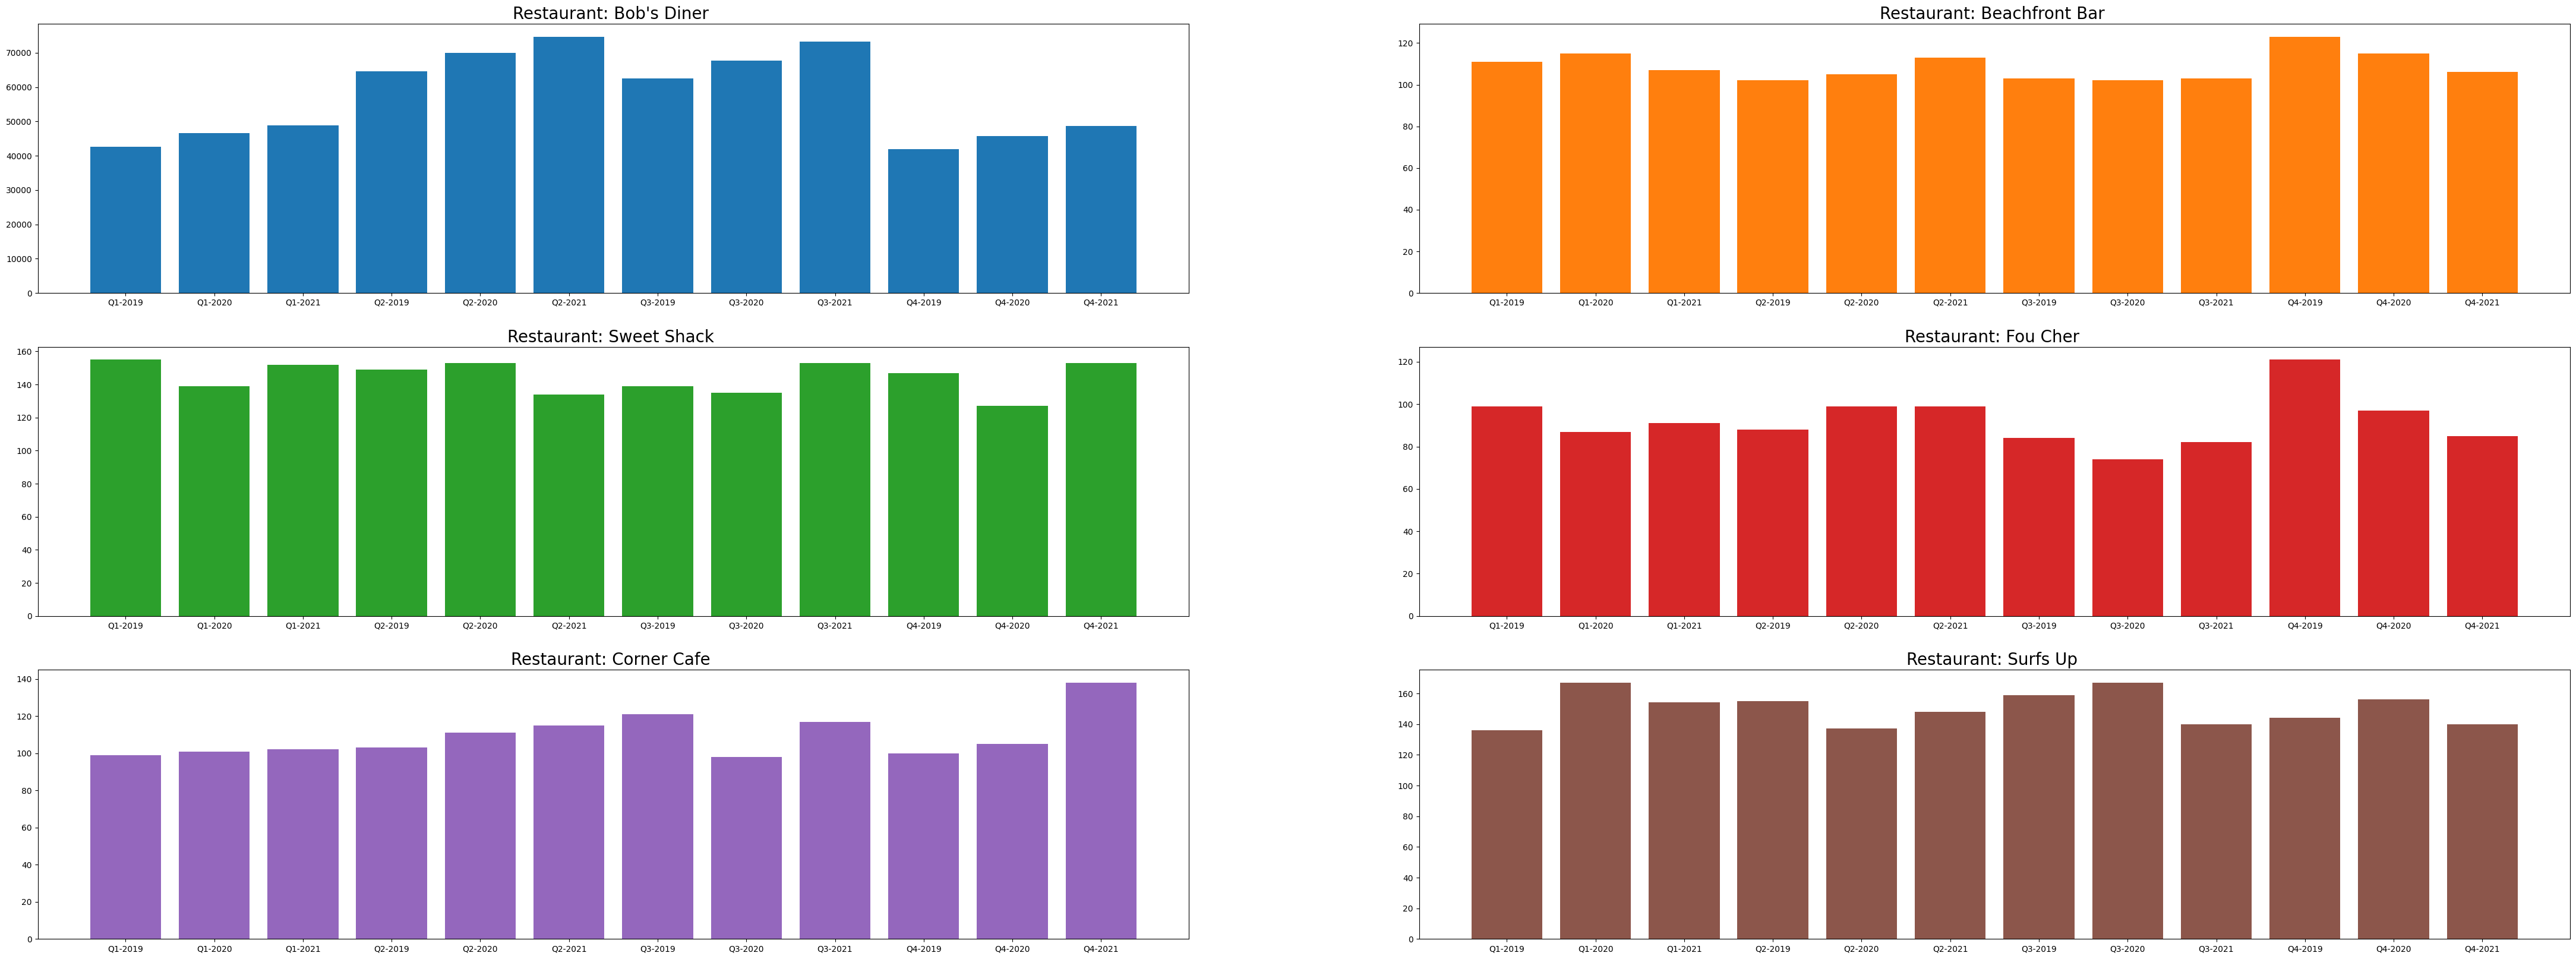

In [243]:
f,ax = plt.subplots(3,2,figsize =(55,20) )
r,c = 0,0
for i in range(1,7):
  ax[r,c].bar(x = plot_data.index,height = plot_data.loc[:, i], color = pal_list[i-1])
  ax[r,c].set_title('Restaurant: {} '.format(df_resturants.loc[df_resturants.id == i, 'name'].values[0]), size = 20)
  c += 1
  if c == 2:
    c = 0
    r +=1

#Month wise sales


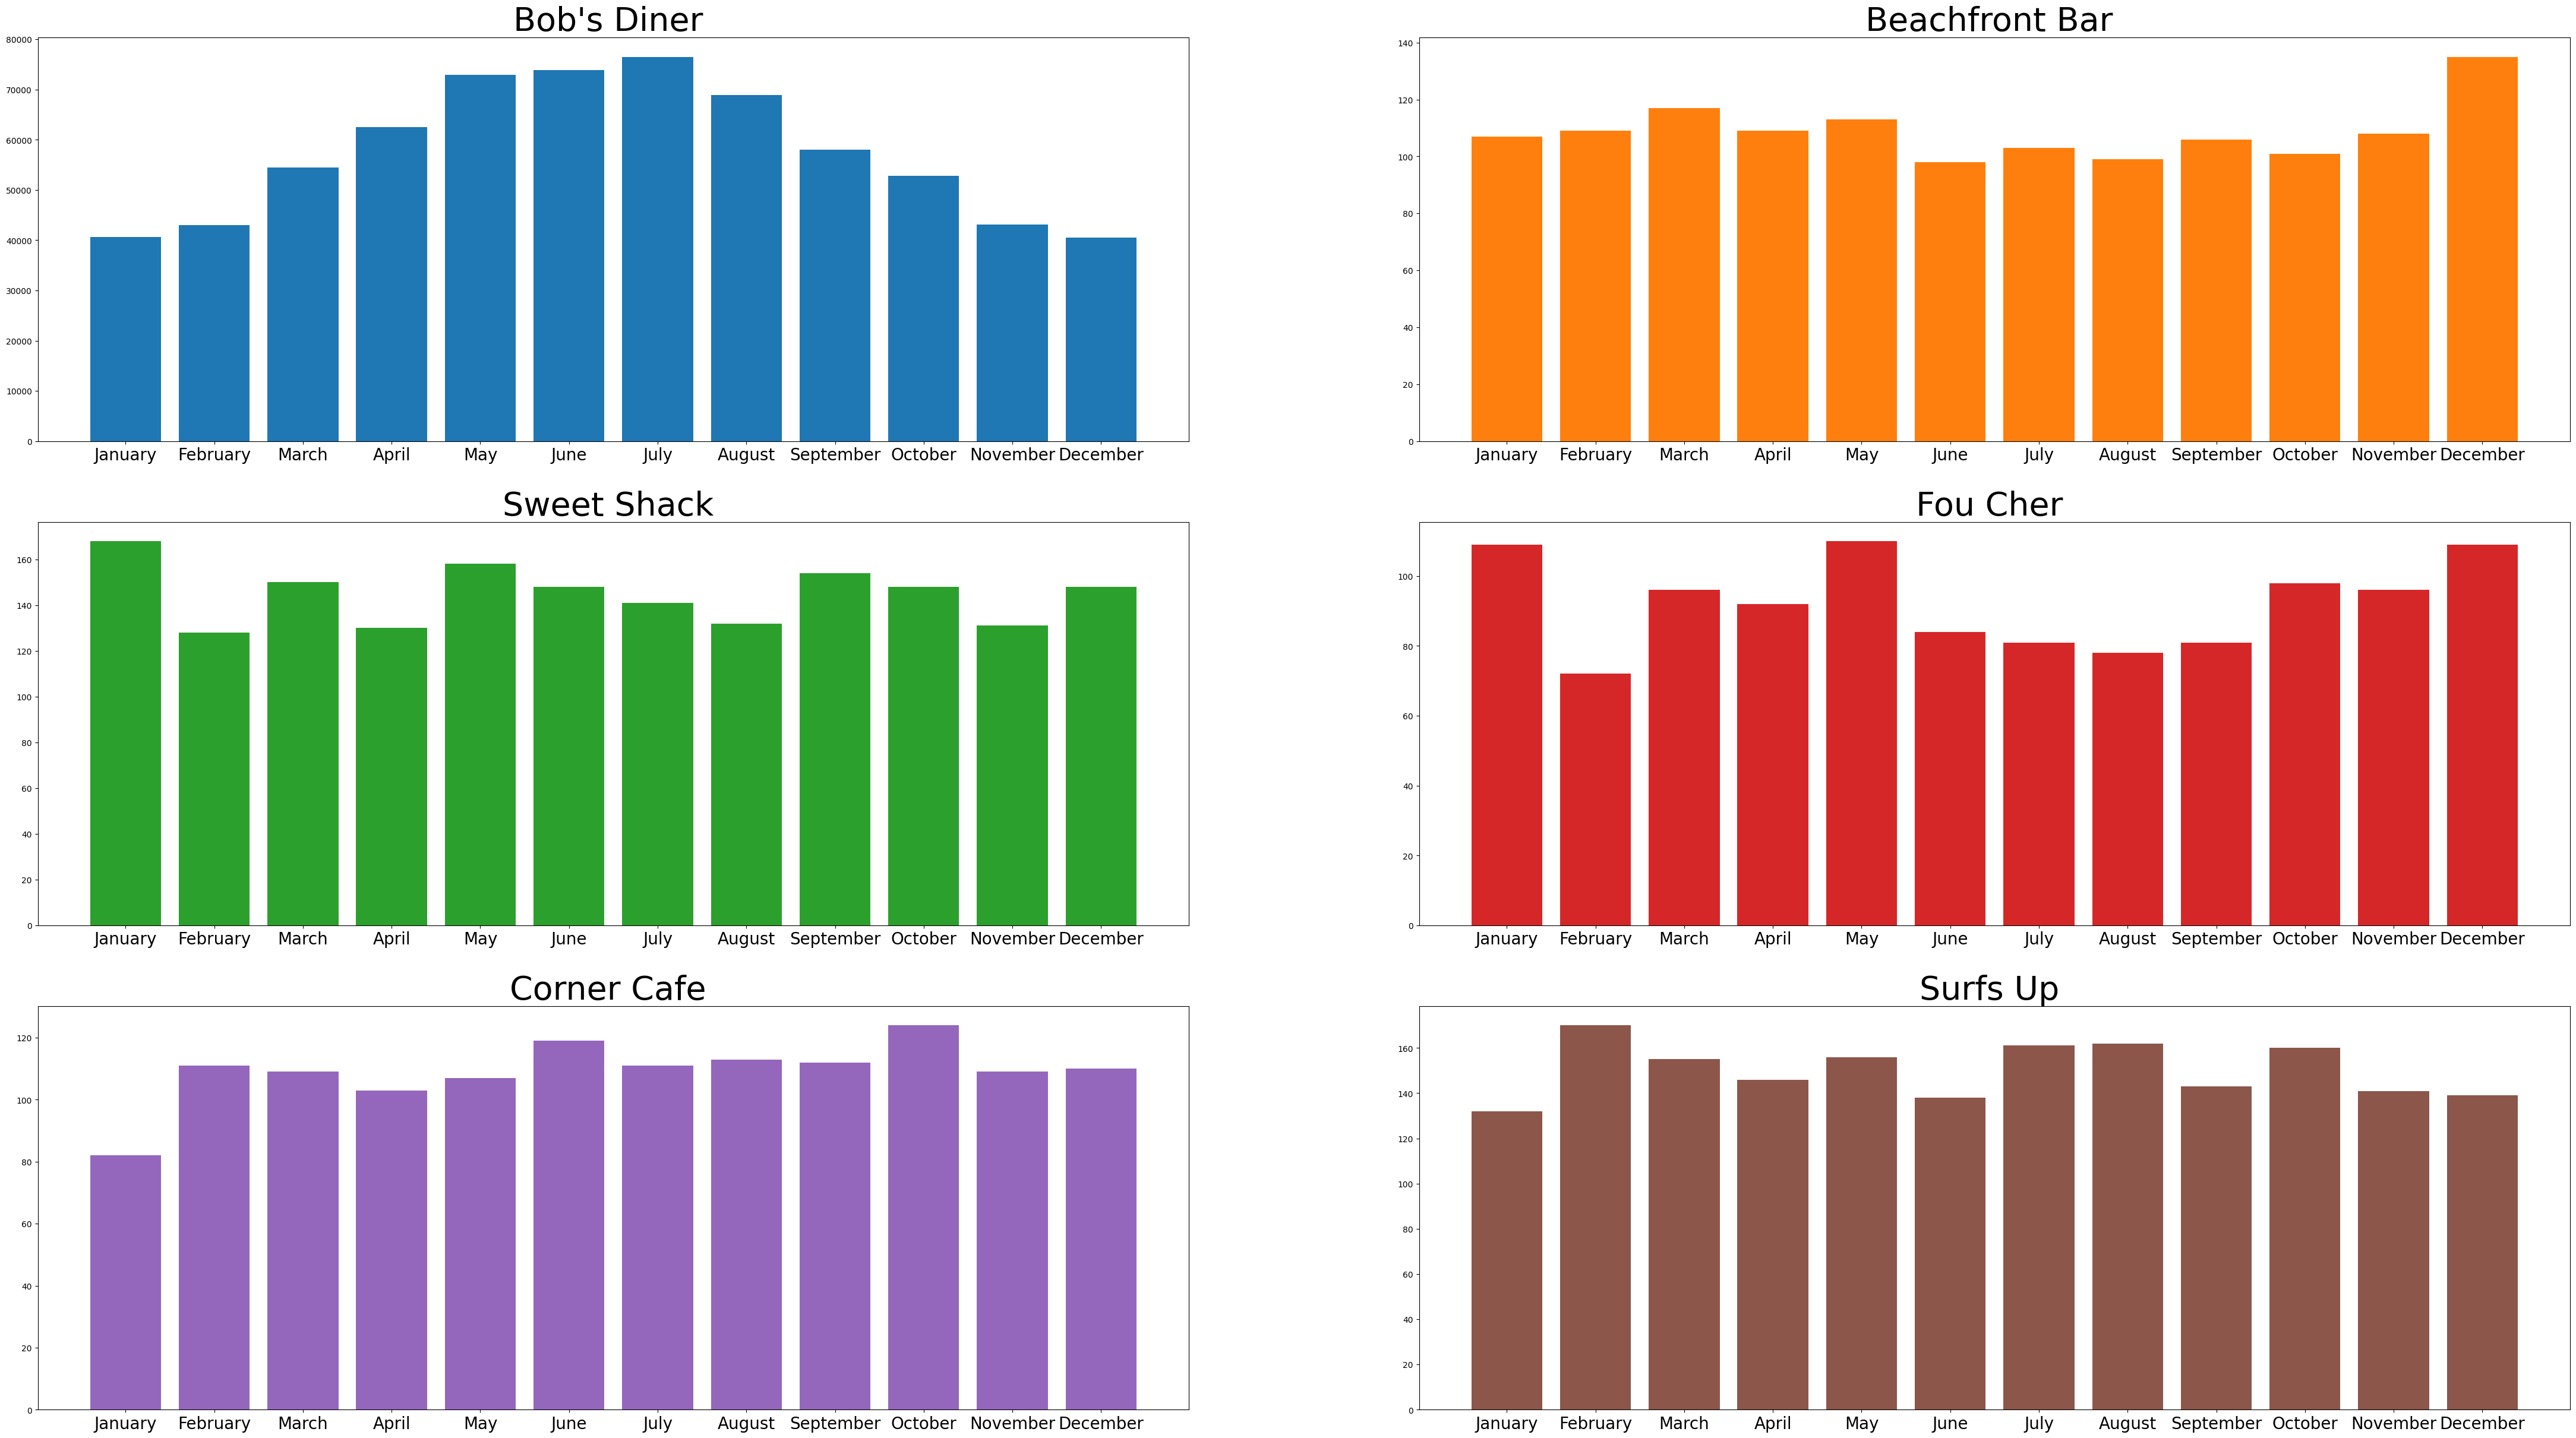

In [244]:
import warnings
warnings.filterwarnings('ignore')
plot_data = df_final_merged_data.pivot_table(index = 'month_name', columns = 'store_id',values = 'item_count', aggfunc = 'sum')
plot_data = plot_data.loc[months]
f,ax = plt.subplots(3,2,figsize =(55,30) )
r,c = 0,0
for i in range(1,7):
  ax[r,c].bar(x = plot_data.index,height = plot_data.loc[:, i], color = pal_list[i-1])
  ax[r,c].set_title('{} '.format(df_resturants.loc[df_resturants.id == i, 'name'].values[0]), size = 40)
  ax[r,c].set_xticklabels(labels = months, fontsize = 20)
  c += 1
  if c == 2:
    c = 0
    r +=1

#Day wise Sales

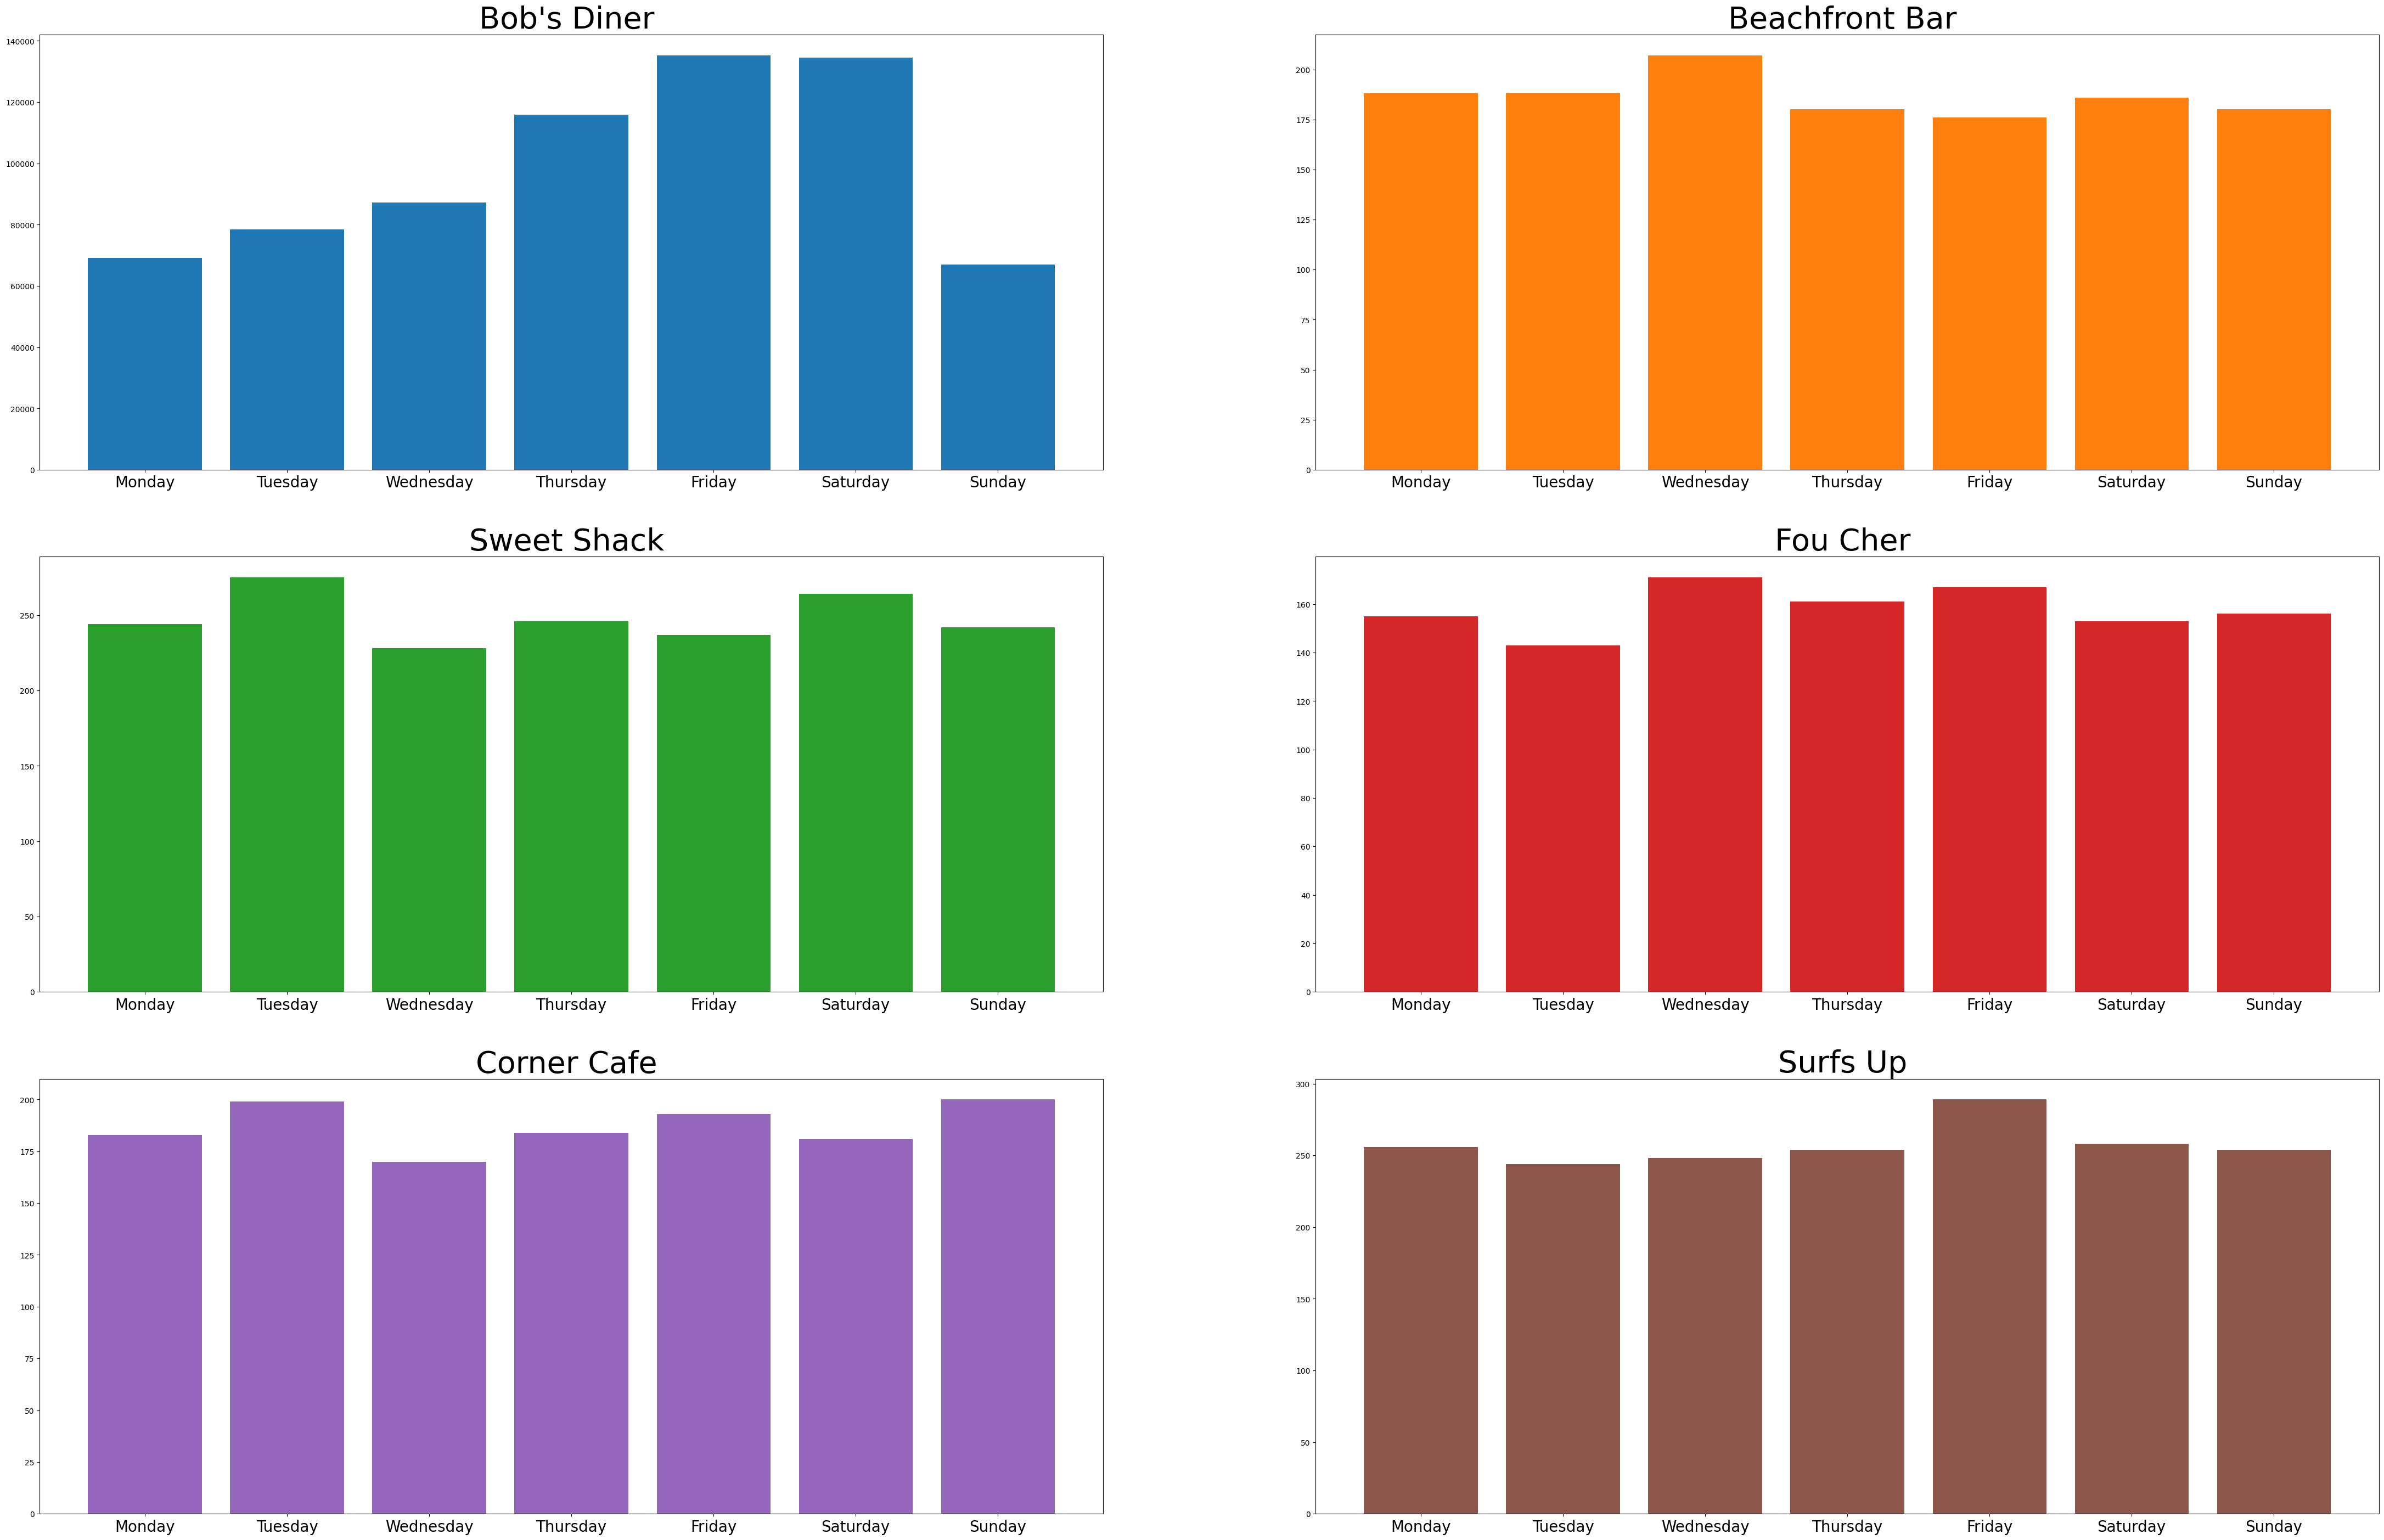

In [245]:
plot_data = df_final_merged_data.pivot_table(index = 'weekday', columns = 'store_id',values = 'item_count', aggfunc = 'sum')
plot_data = plot_data.loc[day_names]
f,ax = plt.subplots(3,2,figsize =(55,35) )
r,c = 0,0
for i in range(1,7):
  ax[r,c].bar(x = plot_data.index,height = plot_data.loc[:, i], color = pal_list[i-1])
  ax[r,c].set_title('{} '.format(df_resturants.loc[df_resturants.id == i, 'name'].values[0]), size = 40)
  ax[r,c].set_xticklabels(labels = day_names, fontsize = 20)
  c += 1
  if c == 2:
    c = 0
    r +=1
plt.show()

#Identify the most popular items overall and the stores where they are being sold. Also, find out the most popular item at each store

In [246]:
plot_data = df_final_merged_data.groupby('item_id')[['item_count']].sum().sort_values('item_count',ascending = False).reset_index()[:5]
final_plot_data = pd.merge(plot_data, df_items, left_on = 'item_id', right_on = 'id', how = 'left')[['item_id', 'item_count', 'name', 'kcal', 'cost', 'store_id']]

#Popular Items

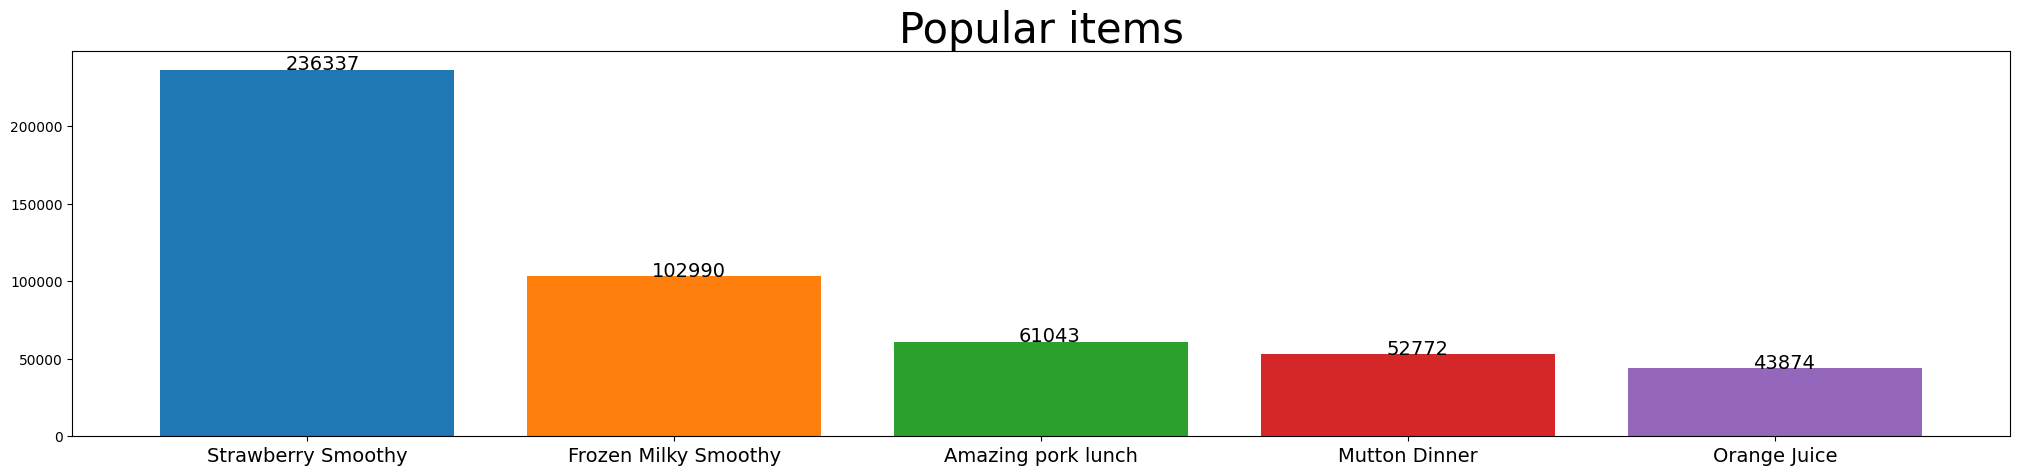

In [247]:

final_plot_data = pd.merge(plot_data, df_items, left_on = 'item_id', right_on = 'id', how = 'left')[['item_id', 'item_count', 'name', 'kcal', 'cost', 'store_id']]
plt.figure(figsize = (25,5))
plt.bar(final_plot_data.name, final_plot_data.item_count, color = pal_list)
plt.title('Popular items', size= 30)
for k in range(5):
  val = final_plot_data.loc[k,'item_count']
  plt.annotate('{:0.0f}'.format(val), xy = (k-0.06, val), size = 14)
plt.xticks(size = 14)
plt.show()

#Popular Items Store wise

In [248]:
count_data = df_final_merged_data.pivot_table(index = 'item_id', columns = 'store_id',values = 'item_count', aggfunc = 'sum', fill_value = 0 )
item_ids = count_data.index[count_data.values.argmax(axis = 0)]

In [250]:
pop_items = df_items.loc[df_items.id.isin(item_ids), ['store_id', 'id', 'name', 'kcal', 'cost']]
pop_data = pd.merge(pop_items, df_resturants, how = 'left', left_on = 'store_id', right_on = 'id', suffixes = ('_item', '_restaurant'))
pop_data['count'] = count_data.loc[item_ids,].sum(axis = 0).reset_index().iloc[:,1]
pop_data = pop_data[['name_restaurant', 'name_item', 'kcal', 'cost', 'count']]
pop_data

,name_restaurant,name_item,kcal,cost,count
0,Bob's Diner,Strawberry Smoothy,145,2.89,236337.0
1,Beachfront Bar,Fantastic Milky Smoothy,318,2.91,1147.0
2,Sweet Shack,Awesome Smoothy,78,1.39,1692.0
3,Corner Cafe,Frozen Milky Smoothy,211,3.98,298.0
4,Fou Cher,Blue Ribbon Fruity Vegi Lunch,881,53.98,273.0
5,Surfs Up,Awesome Soft Drink,248,3.06,997.0


#g. Determine if the store with the highest sales volume is also making the most money per day

In [251]:
df_final_merged_data.groupby('store_id')[['item_count']].sum().reset_index()

,store_id,item_count
0,1,687527.0
1,2,1305.0
2,3,1736.0
3,4,1106.0
4,5,1310.0
5,6,1803.0


In [252]:
df_final_merged_data.pivot_table(index = 'store_id', columns = 'year', values = 'item_count', aggfunc = 'sum')

year,2019,2020,2021
store_id,,,
1,211799.0,230191.0,245537.0
2,439.0,437.0,429.0
3,590.0,554.0,592.0
4,392.0,357.0,357.0
5,423.0,415.0,472.0
6,594.0,627.0,582.0


In [253]:
#Sale Amount column
df_final_merged_data['sales_amnt'] = df_final_merged_data.item_count * df_final_merged_data.price

In [254]:
df_final_merged_data.pivot_table(index = 'store_id', columns = 'year', values = 'sales_amnt', aggfunc = 'sum')

year,2019,2020,2021
store_id,,,
1,1849483.49,2112331.91,2375460.29
2,1281.85,1267.21,1247.14
3,872.59,828.65,877.03
4,9698.80,8590.87,9595.70
5,5292.93,5347.71,5910.79
6,5132.65,5314.43,5204.41


In [255]:
count_order = df_final_merged_data.pivot_table(index = 'store_id',  values = 'sales_amnt', aggfunc = 'sum').squeeze()
count_order_rest = count_order.sort_values(ascending = False).index

In [256]:
count_order

,sales_amnt
store_id,
1,6337275.69
2,3796.20
3,2578.27
4,27885.37
5,16551.43
6,15651.49


In [257]:
count_order_rest #According to money it is 1,4,5,6

Index([1, 4, 5, 6, 2, 3], dtype='int64', name='store_id')

#h. Identify the most expensive item at each restaurant and find out its calorie count

In [260]:
df_items.iloc[[df_items.cost.argmax()]]
#Most Expensive is Blue Riboon

,id,store_id,name,kcal,cost
79,80,4,Blue Ribbon Fruity Vegi Lunch,881,53.98


In [261]:
df_items.groupby('store_id')[['cost']].agg(['max', 'min', 'mean'])

cost                 
            max   min       mean
store_id                        
1         29.22  2.89  12.211667
2          5.70  2.43   3.585000
3          7.70  1.39   5.276250
4         53.98  3.23  12.819643
5         26.37  3.74  13.371667
6         26.21  3.06  13.970000

#ML PART. Forecasting using machine learning algorithms

Build and compare linear regression, random forest, and XGBoost models for predictions

  Generate necessary features for the development of these models, like day of the week, quarter of the year, month, year, day of the month and so on

  Use the data from the last six months as the testing data

  Compute the root mean square error (RMSE) values for each model to compare their performances

  Use the best-performing models to make a forecast for the next year

In [262]:
df_final_merged_data

,date,item_id,price,item_count,store_id,item_name,kcal,restaurant_name,day_of_week,weekday,month_name,quarter,year,quart-year,sales_amnt
0,2019-01-01,3,29.22,2.0,1,Sweet Fruity Cake,931,Bob's Diner,Tuesday,Tuesday,January,1,2019,Q1-2019,58.44
1,2019-01-01,4,26.42,22.0,1,Amazing Steak Dinner with Rolls,763,Bob's Diner,Tuesday,Tuesday,January,1,2019,Q1-2019,581.24
2,2019-01-01,12,4.87,7.0,1,Fantastic Sweet Cola,478,Bob's Diner,Tuesday,Tuesday,January,1,2019,Q1-2019,34.09
3,2019-01-01,13,4.18,12.0,1,Sweet Frozen Soft Drink,490,Bob's Diner,Tuesday,Tuesday,January,1,2019,Q1-2019,50.16
4,2019-01-01,16,3.21,136.0,1,Frozen Milky Smoothy,284,Bob's Diner,Tuesday,Tuesday,January,1,2019,Q1-2019,436.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109595,2021-12-31,96,21.93,0.0,5,Blue Ribbon Fish with Bread Lunch,708,Corner Cafe,Friday,Friday,December,4,2021,Q4-2021,0.00
109596,2021-12-31,97,28.65,0.0,4,Original Fruity Cod with Bread and Vegetables ...,744,Fou Cher,Friday,Friday,December,4,2021,Q4-2021,0.00
109597,2021-12-31,98,5.00,0.0,2,Original Sweet Milky Soft Drink,579,Beachfront Bar,Friday,Friday,December,4,2021,Q4-2021,0.00
109598,2021-12-31,99,5.32,0.0,4,Frozen Tomato Soft Drink,423,Fou Cher,Friday,Friday,December,4,2021,Q4-2021,0.00


In [263]:
#generate the additonal columns
time_series = df_final_merged_data.groupby(['date']).agg({'item_count':'sum', 'weekday': lambda x :x.unique()[0],
                            'quarter' : lambda x :x.unique()[0], 'year': lambda x :x.unique()[0],
                            'month_name' : lambda x :x.unique()[0],
                            'year':lambda x :x.unique()[0]})
time_series

,item_count,weekday,quarter,year,month_name
date,,,,,
2019-01-01,427.0,Tuesday,1,2019,January
2019-01-02,337.0,Wednesday,1,2019,January
2019-01-03,445.0,Thursday,1,2019,January
2019-01-04,564.0,Friday,1,2019,January
2019-01-05,552.0,Saturday,1,2019,January
...,...,...,...,...,...
2021-12-27,192.0,Monday,4,2021,December
2021-12-28,344.0,Tuesday,4,2021,December
2021-12-29,371.0,Wednesday,4,2021,December


In [264]:
#add more features to the Data

time_series['day_year'] = time_series.index.day_of_year
time_series['day_month'] = time_series.index.day
time_series['week_num'] = time_series.index.isocalendar().week.astype(int)
time_series



,item_count,weekday,quarter,year,month_name,day_year,day_month,week_num
date,,,,,,,,
2019-01-01,427.0,Tuesday,1,2019,January,1,1,1
2019-01-02,337.0,Wednesday,1,2019,January,2,2,1
2019-01-03,445.0,Thursday,1,2019,January,3,3,1
2019-01-04,564.0,Friday,1,2019,January,4,4,1
2019-01-05,552.0,Saturday,1,2019,January,5,5,1
...,...,...,...,...,...,...,...,...
2021-12-27,192.0,Monday,4,2021,December,361,27,52
2021-12-28,344.0,Tuesday,4,2021,December,362,28,52
2021-12-29,371.0,Wednesday,4,2021,December,363,29,52


Convert the Catgeorical data to numerical data


In [265]:
from sklearn.preprocessing import OrdinalEncoder

In [266]:
df_final_merged_data['month_name'] = df_final_merged_data['date'].dt.month_name()
months = list(cal.month_name)[1:]

ord_enc1 = OrdinalEncoder(categories = [months, day_names])
ord_enc1.fit(time_series[['month_name', 'weekday']])
time_series[['month_name', 'weekday']] = ord_enc1.transform(time_series[['month_name', 'weekday']])

In [267]:
time_series

,item_count,weekday,quarter,year,month_name,day_year,day_month,week_num
date,,,,,,,,
2019-01-01,427.0,1.0,1,2019,0.0,1,1,1
2019-01-02,337.0,2.0,1,2019,0.0,2,2,1
2019-01-03,445.0,3.0,1,2019,0.0,3,3,1
2019-01-04,564.0,4.0,1,2019,0.0,4,4,1
2019-01-05,552.0,5.0,1,2019,0.0,5,5,1
...,...,...,...,...,...,...,...,...
2021-12-27,192.0,0.0,4,2021,11.0,361,27,52
2021-12-28,344.0,1.0,4,2021,11.0,362,28,52
2021-12-29,371.0,2.0,4,2021,11.0,363,29,52


Train the Model

In [268]:
#it is last 6 months data
train = time_series[time_series.index < '2021-07-01'] #train data
test = time_series[time_series.index >= '2021-07-01'] #test data




In [269]:
#Creat dependent and independent variable

y_var = 'item_count'
x_vars = time_series.drop(columns = 'item_count').columns

X_train = train[x_vars]
Y_train = train[y_var]
X_test = test[x_vars]
Y_test = test[y_var]

#Import the Library for ML

In [270]:
#Import the Libraries for the ML

# for prediction models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM
from tensorflow.keras.callbacks import EarlyStopping
# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
# plt.style.use("fivethirtyeight")
pal = sns.color_palette()
pal_list = list(pal)
# for image study
import torch
import datetime as dt
import os
import tqdm

#Linear Regression

In [271]:
lr = LinearRegression()
lr.fit(X_train, Y_train)

LinearRegression()

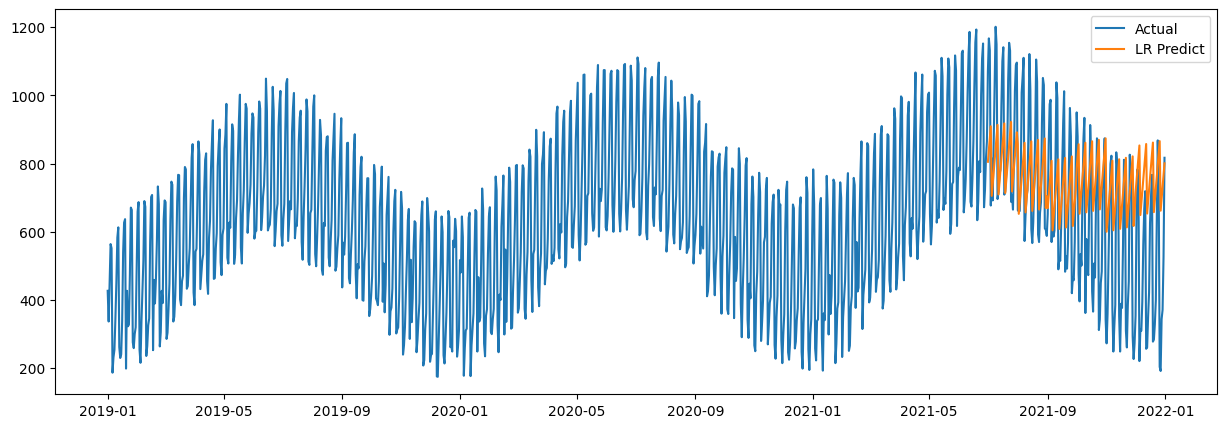

Linear Regression :
RMSE : 59638.94
MAE : 196.04
R2_Score : 7.65


In [272]:
test['lr_pred'] = lr.predict(X_test)
plt.figure(figsize = (15,5))
plt.plot(time_series.item_count, label = "Actual")
plt.plot(test.lr_pred, label = "LR Predict")
plt.legend()
plt.show()
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
lr_rmse = mean_squared_error(y_true = test.item_count, y_pred = test.lr_pred)
lr_mae = mean_absolute_error(y_true = test.item_count, y_pred = test.lr_pred)
lr_r2_score = r2_score(y_true = test.item_count, y_pred = test.lr_pred)
print("Linear Regression :\nRMSE : {:.2f}\nMAE : {:.2f}\nR2_Score : {:.2f}".format(lr_rmse,lr_mae,lr_r2_score*100))

In [274]:
results = pd.DataFrame([lr_rmse, lr_mae,lr_r2_score*100], index = ['RMSE', 'MAE', 'R2_Score'], columns = ['Linear Regression']).round(2)
results

,Linear Regression
RMSE,59638.94
MAE,196.04
R2_Score,7.65


In [197]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, max_depth=20)
rf.fit(X_train, Y_train)

RandomForestRegressor(max_depth=20)

In [275]:
test['rf_pred'] = rf.predict(X_test)
rf_rmse = mean_squared_error(y_true = test.item_count, y_pred = test.rf_pred)
rf_mae = mean_absolute_error(y_true = test.item_count, y_pred = test.rf_pred)
rf_r2_score = r2_score(y_true = test.item_count, y_pred = test.rf_pred)
print("Random Forest Regression :\nRMSE : {:.2f}\nMAE : {:.2f}\nR2_Score : {:.2f}".format(rf_rmse,rf_mae,rf_r2_score*100))
results['Random Forest'] = [rf_rmse,rf_mae,rf_r2_score*100]
results.round(2)

Random Forest Regression :
RMSE : 3599.75
MAE : 47.92
R2_Score : 94.43


,Linear Regression,Random Forest
RMSE,59638.94,3599.75
MAE,196.04,47.92
R2_Score,7.65,94.43


#XGBOOST

In [276]:
import xgboost as xgb
xgb = xgb.XGBRegressor(base_score=0.5, booster='gbtree',
                       n_estimators=1000,
                       early_stopping_rounds=50,
                       objective='reg:linear',
                       max_depth=3,
                       learning_rate=0.01)
xgb.fit(X_train, Y_train,
        eval_set=[(X_train, Y_train), (X_test, Y_test)],
        verbose=100)

[0]	validation_0-rmse:660.07727	validation_1-rmse:709.00674
[100]	validation_0-rmse:262.48189	validation_1-rmse:311.68003
[200]	validation_0-rmse:121.24482	validation_1-rmse:170.88932
[300]	validation_0-rmse:71.52864	validation_1-rmse:105.59530
[400]	validation_0-rmse:52.24901	validation_1-rmse:78.69102
[500]	validation_0-rmse:43.97728	validation_1-rmse:72.77059
[589]	validation_0-rmse:40.37765	validation_1-rmse:73.71554


XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

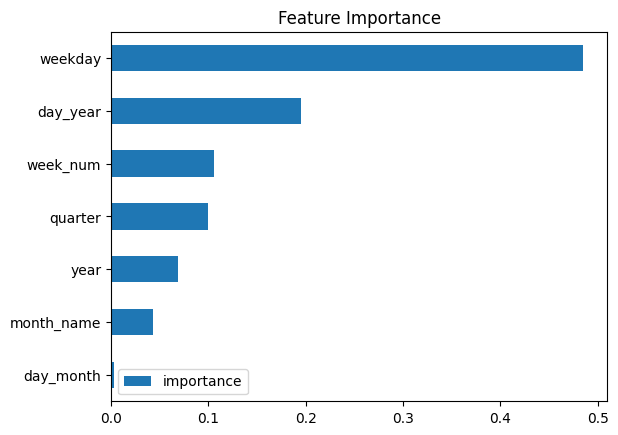

In [277]:
importance = pd.DataFrame(data=xgb.feature_importances_,
             index=xgb.get_booster().feature_names,
             columns=['importance'])
importance.sort_values('importance').plot(kind='barh', title='Feature Importance')
plt.show()

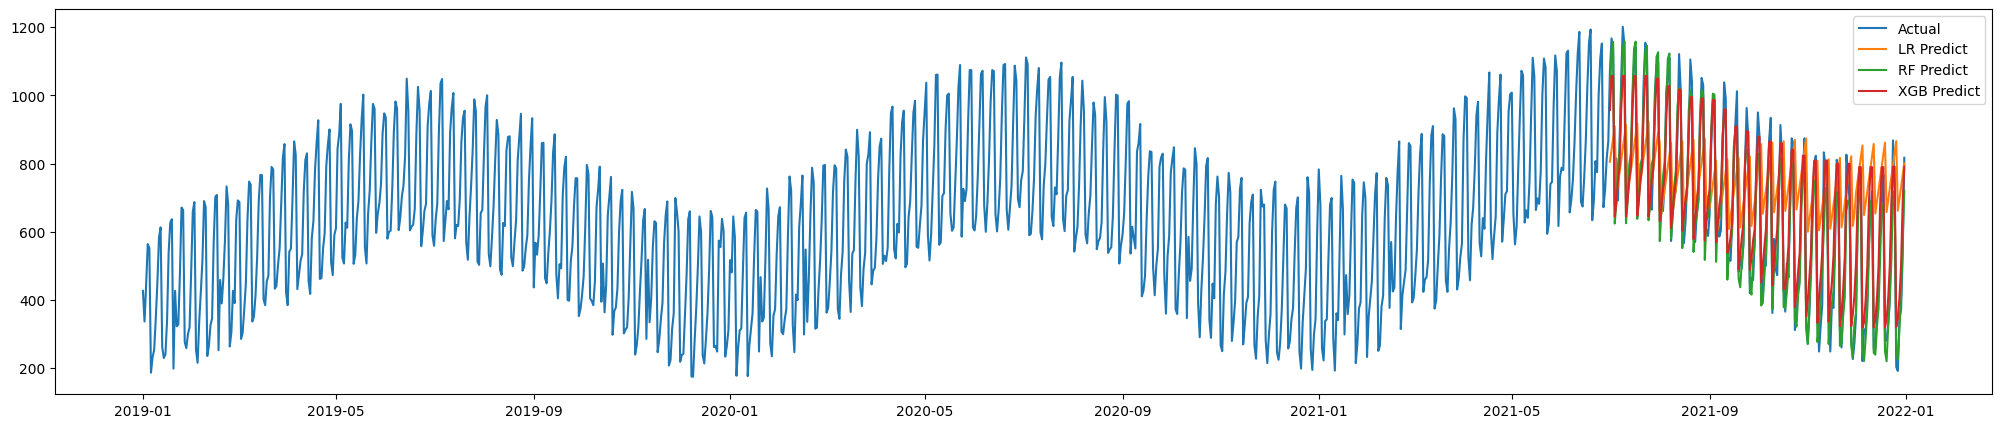

In [278]:
test['xgb_pred'] = xgb.predict(X_test)
plt.figure(figsize = (25,5))
plt.plot(time_series.item_count, label = "Actual")
plt.plot(test.lr_pred, label = "LR Predict")
plt.plot(test.rf_pred, label = "RF Predict")
plt.plot(test.xgb_pred, label = "XGB Predict")
plt.legend()
plt.show()

In [279]:
xgb_rmse = mean_squared_error(y_true = test.item_count, y_pred = test.xgb_pred)
xgb_mae = mean_absolute_error(y_true = test.item_count, y_pred = test.xgb_pred)
xgb_r2_score = r2_score(y_true = test.item_count, y_pred = test.xgb_pred)
print("XGBoost :\nRMSE : {:.2f}\nMAE : {:.2f}\nR2_Score : {:.2f}".format(xgb_rmse,xgb_mae,xgb_r2_score*100))

XGBoost :
RMSE : 5263.64
MAE : 59.58
R2_Score : 91.85


In [280]:
results['XGBoost'] = [xgb_rmse,xgb_mae,xgb_r2_score*100]
results = results.round(2)

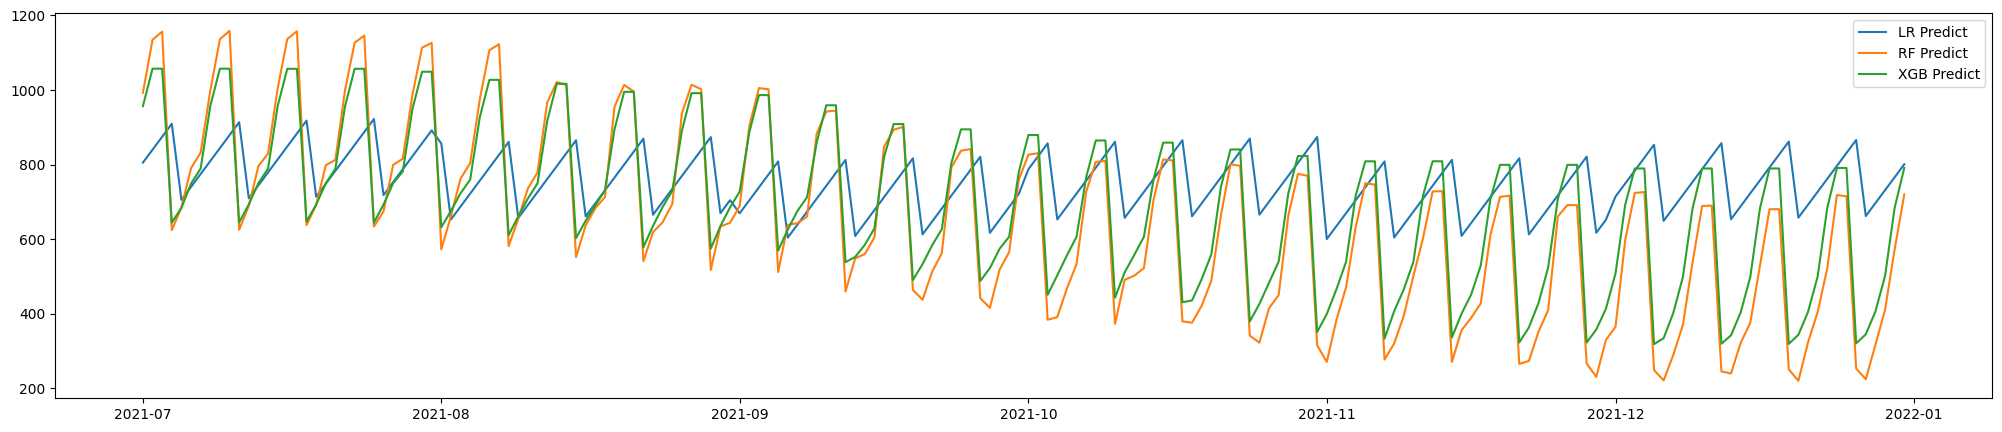

In [281]:
plt.figure(figsize = (25,5))
plt.plot(test.lr_pred, label = "LR Predict")
plt.plot(test.rf_pred, label = "RF Predict")
plt.plot(test.xgb_pred, label = "XGB Predict")
plt.legend()
plt.show()

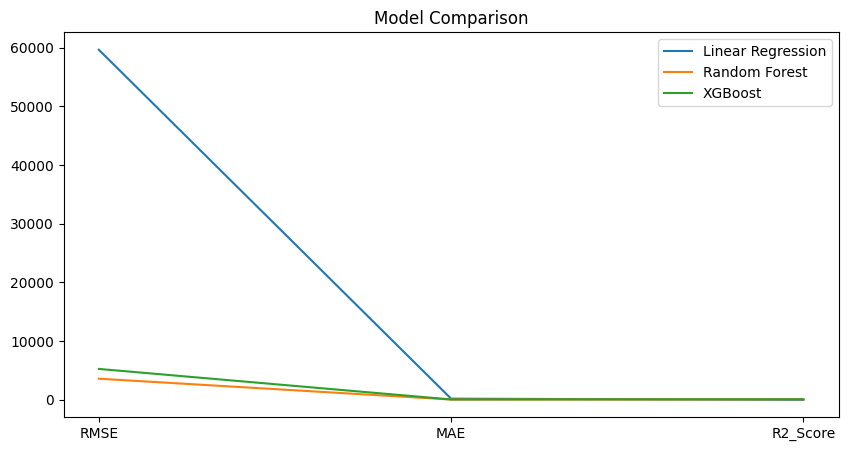

In [282]:
plt.figure(figsize = (10,5))
plt.plot(results['Linear Regression'], label = "Linear Regression")
plt.plot(results['Random Forest'], label = "Random Forest")
plt.plot(results['XGBoost'], label = "XGBoost")
plt.legend(loc = "upper right")
plt.title("Model Comparison")
plt.show()

In [283]:
future_predictors = pd.DataFrame(pd.date_range(start="2022-01-01", end="2022-12-31"), columns=['date'])
future_predictors.index = pd.to_datetime(future_predictors.date)

In [284]:
future_predictors['weekday'] = future_predictors.date.dt.day_name()
future_predictors['quarter'] = future_predictors.date.dt.quarter
future_predictors['year'] = future_predictors.date.dt.year
future_predictors['month_name'] = future_predictors.date.dt.month_name()
future_predictors['day_year'] = future_predictors.date.dt.day_of_year
future_predictors['day_month'] = future_predictors.date.dt.day
future_predictors['week_num'] = future_predictors.date.dt.isocalendar().week

In [285]:
future_predictors[['month_name', 'weekday']] = ord_enc1.transform(future_predictors[['month_name', 'weekday']])

In [286]:
future_predictors['predictions'] = rf.predict(future_predictors[X_train.columns])

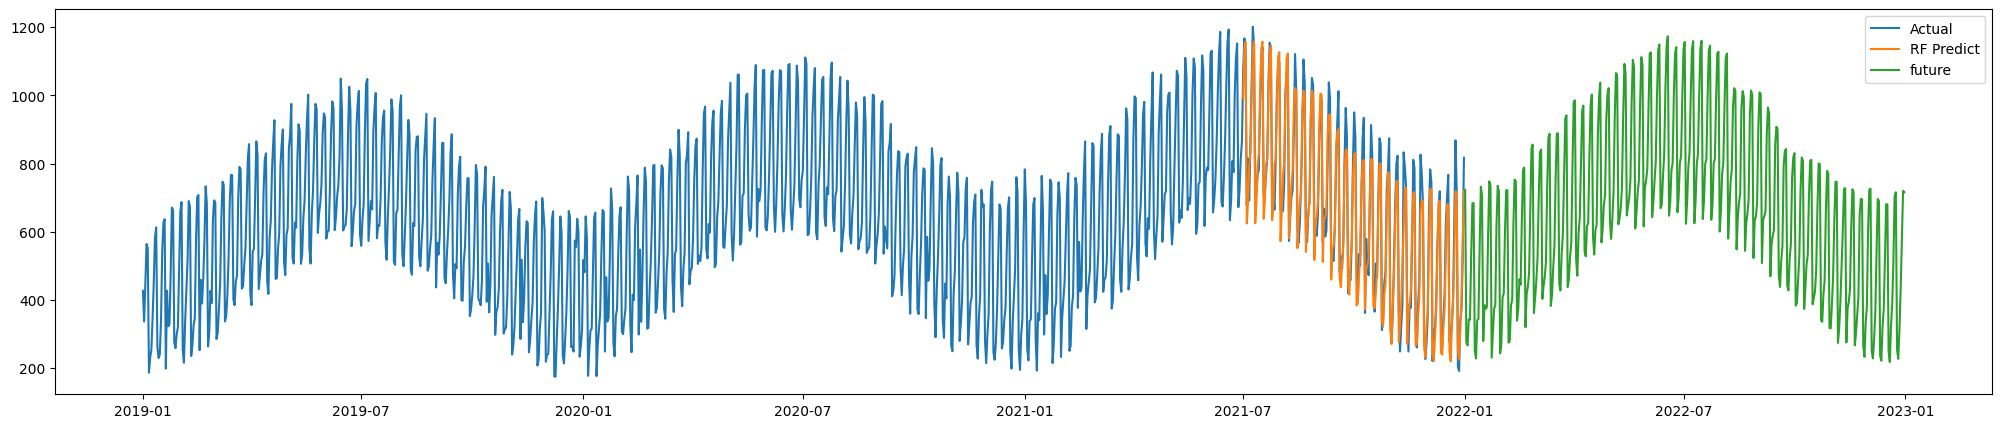

In [287]:
plt.figure(figsize = (25,5))
plt.plot(time_series.item_count, label = "Actual")
plt.plot(test.rf_pred, label = "RF Predict")
plt.plot(future_predictors.predictions, label = "future")
plt.legend()
plt.show()